In [59]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, classification_report, make_scorer

In [60]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Размер датасета: {df.shape}")
df.info()

Размер датасета: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

In [61]:
#TotalCharges -shouldn't be an object - null or spaces

Доля оттока: 26.5%
Базовая точность: 73.5%


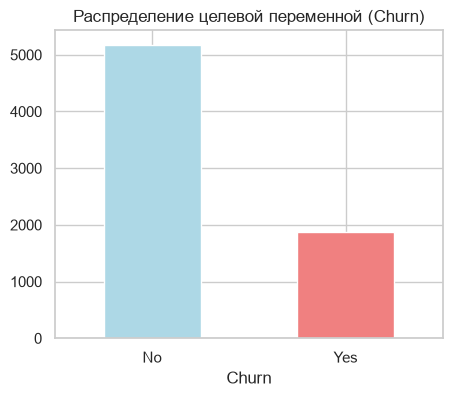

In [62]:
#Churn
counts = df['Churn'].value_counts()

print(f"Доля оттока: {counts['Yes'] / counts.sum():.1%}")
print(f"Базовая точность: {counts['No'] / counts.sum():.1%}")


counts.plot(kind='bar', color=['lightblue', 'lightcoral'], figsize=(5, 4), rot=0)

plt.title('Распределение целевой переменной (Churn)')
plt.show()

In [63]:
#гипотезы:
#1. Новые клиенты (низкий `tenure`) уходят чаще всего. Имеет смысл разбить их на корзины.
#2. Чем больше услуг подключено у пользователя, тем сложнее ему уйти (выше «стоимость переключения»).
#3. Высокая среднемесячная нагрузка по отношению к общему сроку — триггер к уходу.

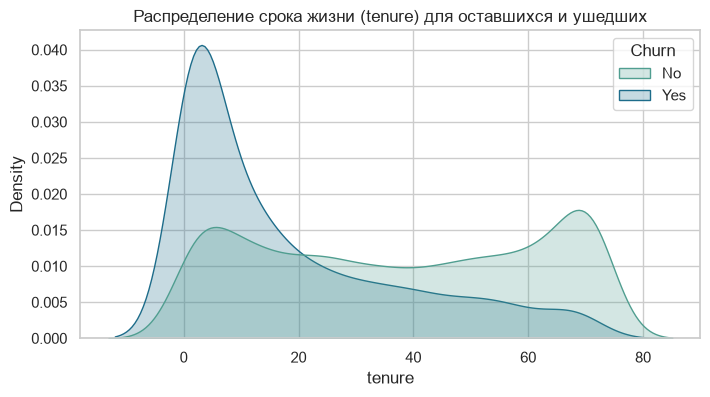

In [64]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Распределение срока жизни (tenure) для оставшихся и ушедших')
plt.show()

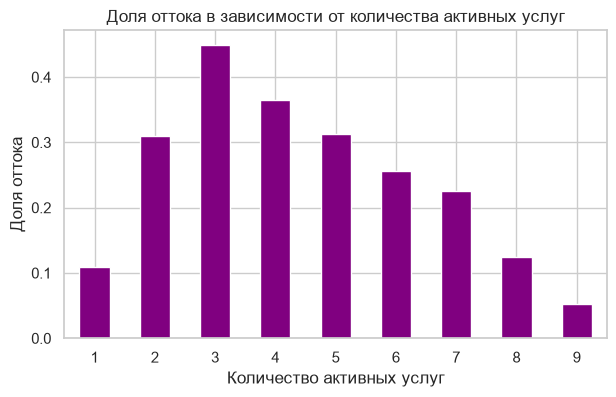

In [65]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
not_active = {'No', 'No internet service', 'No phone service'}

# 1. Считаем количество активных услуг одной строкой 
# .isin(not_active) находит неактивные, ~ переворачивает в активные, .sum(axis=1) считает их сумму для каждой строки
n_services = (~df[service_cols].isin(not_active)).sum(axis=1)

# 2. Переводим Churn в числа (1 и 0) и группируем по количеству услуг
churn_numeric = (df['Churn'] == 'Yes').astype(int)
churn_by_services = churn_numeric.groupby(n_services).mean()

# 3. График
churn_by_services.plot(kind='bar', color='purple', figsize=(7, 4), rot=0)

plt.title('Доля оттока в зависимости от количества активных услуг')
plt.xlabel('Количество активных услуг')
plt.ylabel('Доля оттока')
plt.show()

In [66]:
#Чем услуг больше, тем отток ниже. Добавляем признак `n_services`

In [67]:
#train/test split 

y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['Churn', 'customerID'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка:  {X_test.shape[0]} строк")

Обучающая выборка: 5634 строк
Тестовая выборка:  1409 строк


In [68]:
from sklearn.base import BaseEstimator, TransformerMixin

class FixTotalCharges(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_out = X.copy()
        X_out.loc[:, 'TotalCharges'] = pd.to_numeric(X_out['TotalCharges'], errors='coerce')
        return X_out
    def get_feature_names_out(self, input_features=None):
        return input_features

class AddFeatures(BaseEstimator, TransformerMixin):
    SERVICE_COLS = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    NOT_ACTIVE = {'No', 'No internet service', 'No phone service'}

    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_out = X.copy()
        tenure_ser = pd.to_numeric(X_out['tenure'], errors='coerce').fillna(0)
        
        bucket_ser = pd.cut(
            tenure_ser, bins=[-1, 12, 24, 48, np.inf],
            labels=['0-12', '13-24', '25-48', '49+']
        ).astype(str)

        total_ser = pd.to_numeric(X_out['TotalCharges'], errors='coerce').fillna(0)
        charges_per_tenure_ser = total_ser / tenure_ser.clip(lower=1)

        n_services_ser = pd.Series(0, index=X_out.index)
        for col in self.SERVICE_COLS:
            if col in X_out.columns:
                n_services_ser += (~X_out[col].isin(self.NOT_ACTIVE)).astype(int)

        X_out = X_out.assign(
            tenure_bucket=bucket_ser,
            charges_per_tenure=charges_per_tenure_ser,
            n_services=n_services_ser
        )
        return X_out

    def get_feature_names_out(self, input_features=None):
        if input_features is None: return None
        features = list(input_features)
        for col in ['tenure_bucket', 'charges_per_tenure', 'n_services']:
            if col not in features: features.append(col)
        return np.array(features, dtype=object)

In [69]:
NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure', 'n_services']
CAT_COLS = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_bucket']

def make_pipeline(classifier):
    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler())
        ]), NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ], remainder='drop')

    pipe = Pipeline([
        ('fix', FixTotalCharges()),   
        ('features', AddFeatures()),        
        ('prep', preprocessor),         
        ('model', classifier),           
    ])
    pipe.set_output(transform="pandas")
    return pipe

# Настройка метрик для кросс-валидации
scoring = {
    'recall': 'recall',
    'precision': make_scorer(precision_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc'
}

models = {
    'DummyMostFrequent': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Модель':<22} {'Recall':>8} {'Precision':>10} {'F1':>6} {'ROC-AUC':>8}")
print('-' * 56)

for name, clf in models.items():
    pipe = make_pipeline(clf)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    
    print(f"{name:<22} {scores['test_recall'].mean():.3f} {scores['test_precision'].mean():>10.3f} {scores['test_f1'].mean():>6.3f} {scores['test_roc_auc'].mean():>8.3f}")

Модель                   Recall  Precision     F1  ROC-AUC
--------------------------------------------------------
DummyMostFrequent      0.000      0.000  0.000    0.500
LogisticRegression     0.797      0.517  0.627    0.846
RandomForest           0.465      0.639  0.538    0.823
GradientBoosting       0.520      0.660  0.582    0.847


In [70]:
base_pipe = make_pipeline(GradientBoostingClassifier(random_state=42))

param_grid = {
    'model__n_estimators':  [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth':     [3, 4],
}

search = GridSearchCV(base_pipe, param_grid, cv=cv, scoring='average_precision', n_jobs=1, refit=True)
search.fit(X_train, y_train)

best_pipe = search.best_estimator_
print(f"Лучшие параметры: {search.best_params_}")
print(f"Лучший CV PR-AUC: {search.best_score_:.4f}")

Лучшие параметры: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Лучший CV PR-AUC: 0.6690


Оптимальный порог: 0.2642


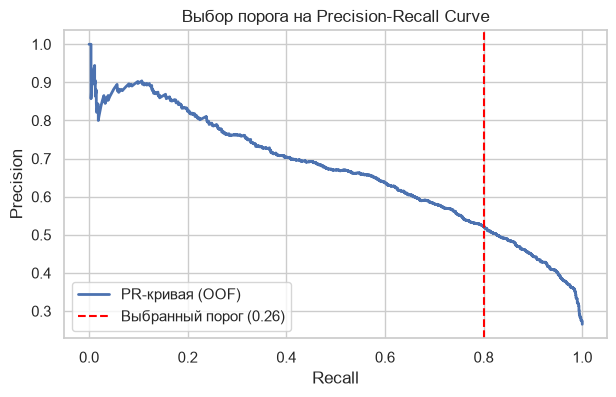

In [71]:
oof_proba = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)

# Ищем порог, где recall максимально близок к 0.80 сверху
mask = recalls[:-1] >= 0.80
best_idx = np.where(mask)[0][np.argmax(precisions[:-1][mask])]
best_threshold = thresholds[best_idx]

print(f"Оптимальный порог: {best_threshold:.4f}")

# Кривая Precision-Recall
plt.figure(figsize=(7, 4))
plt.plot(recalls, precisions, lw=2, label='PR-кривая (OOF)')
plt.axvline(recalls[best_idx], color='red', linestyle='--', label=f'Выбранный порог ({best_threshold:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Выбор порога на Precision-Recall Curve')
plt.legend()
plt.show()

Финальный Recall:    0.7968 (Цель >= 0.75)
Финальная Precision: 0.5183 (Цель >= 0.45)
Финальный ROC-AUC:   0.8441

Отчет о классификации:
              precision    recall  f1-score   support

        Stay       0.91      0.73      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409



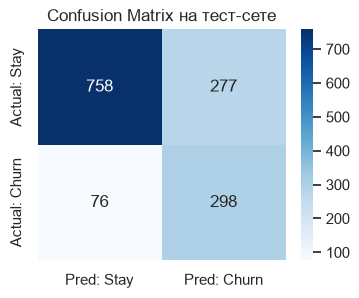

In [72]:
y_proba_test = best_pipe.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= best_threshold).astype(int)

print(f"Финальный Recall:    {recall_score(y_test, y_pred_test):.4f} (Цель >= 0.75)")
print(f"Финальная Precision: {precision_score(y_test, y_pred_test):.4f} (Цель >= 0.45)")
print(f"Финальный ROC-AUC:   {roc_auc_score(y_test, y_proba_test):.4f}")

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_test, target_names=['Stay', 'Churn']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Stay', 'Pred: Churn'], 
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title('Confusion Matrix на тест-сете')
plt.show()